# Dataset Statistics: Real vs Sim

Memory-efficient: streams through h5 files one at a time, accumulates histograms incrementally.

Inspects distributions of `u`, `v` (both real and sim), `p` (sim only), and Mach number `Ma = |V|/a`.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SIM_DIR = Path(r"D:\MyML\realpde\data\train_sim")
REAL_DIR = Path(r"D:\MyML\realpde\data\train_real")

SPEED_OF_SOUND = 343.0  # m/s, air at ~20 C
SUB_S = 2  # spatial subsampling factor
FRAME_STRIDE = 5  # only sample every Nth frame to reduce memory

# Fixed bin edges for all histograms
BINS_UV = np.linspace(-2, 2, 200)
BINS_P = np.linspace(-1, 1, 200)
BINS_SPEED = np.linspace(0, 2, 200)
BINS_MA = np.linspace(0, 2 / SPEED_OF_SOUND, 200)

## 1. Incremental histogram accumulator

In [2]:
def stream_histograms(data_dir, bins_dict, has_p=True, frame_stride=FRAME_STRIDE):
    """
    Stream through h5 files, compute histograms for each variable in bins_dict.
    bins_dict: {"var_name": (var_array_or_callable, bin_edges), ...}
    Returns {var: (counts, bin_edges)} and per-file scalar stats.
    """
    files = sorted(data_dir.glob("*.h5"))
    # Initialize accumulators
    hist_counts = {k: None for k in bins_dict}
    running_sum = {k: 0.0 for k in bins_dict}
    running_sum2 = {k: 0.0 for k in bins_dict}
    running_min = {k: np.inf for k in bins_dict}
    running_max = {k: -np.inf for k in bins_dict}
    total_n = 0
    file_stats = []

    for f in files:
        with h5py.File(f, "r") as h:
            u_raw = np.asarray(h["u"][::frame_stride, ::SUB_S, ::SUB_S], dtype=np.float32)
            v_raw = np.asarray(h["v"][::frame_stride, ::SUB_S, ::SUB_S], dtype=np.float32)
            if has_p and "p" in h:
                p_raw = np.asarray(h["p"][::frame_stride, ::SUB_S, ::SUB_S], dtype=np.float32)
            else:
                p_raw = np.zeros_like(u_raw)
            speed_raw = np.sqrt(u_raw**2 + v_raw**2)
            ma_raw = speed_raw / SPEED_OF_SOUND

            # Map variable names to arrays
            arrays = {"u": u_raw, "v": v_raw, "p": p_raw, "speed": speed_raw, "ma": ma_raw}

            n = u_raw.size
            total_n += n

            # Per-file stats (tiny memory)
            file_stats.append({
                "file": f.stem,
                "re": int(h["re"][()]),
                "aoa": int(h["aoa"][()]),
                "u_mean": float(u_raw.mean()), "u_std": float(u_raw.std()),
                "v_mean": float(v_raw.mean()), "v_std": float(v_raw.std()),
                "p_mean": float(p_raw.mean()), "p_std": float(p_raw.std()),
                "speed_mean": float(speed_raw.mean()),
                "ma_mean": float(ma_raw.mean()),
            })

            # Accumulate histograms and running stats
            for k, (arr_key, edges) in bins_dict.items():
                arr = arrays[arr_key].ravel()
                counts, _ = np.histogram(arr, bins=edges)
                if hist_counts[k] is None:
                    hist_counts[k] = counts.astype(np.float64)
                else:
                    hist_counts[k] += counts
                running_sum[k] += arr.sum()
                running_sum2[k] += (arr**2).sum()
                running_min[k] = min(running_min[k], float(arr.min()))
                running_max[k] = max(running_max[k], float(arr.max()))

    # Normalize histograms to density
    result = {}
    stats = {}
    for k in bins_dict:
        counts = hist_counts[k]
        edges = bins_dict[k][1]
        bin_widths = np.diff(edges)
        density = counts / (counts.sum() * bin_widths)
        result[k] = (density, edges)
        mean = running_sum[k] / total_n
        std = np.sqrt(running_sum2[k] / total_n - mean**2)
        stats[k] = {
            "min": running_min[k], "max": running_max[k],
            "mean": mean, "std": std,
            "n": total_n,
        }
    return result, stats, file_stats

## 2. Stream sim data

In [3]:
sim_bins_def = {
    "u": ("u", BINS_UV),
    "v": ("v", BINS_UV),
    "p": ("p", BINS_P),
    "speed": ("speed", BINS_SPEED),
    "ma": ("ma", BINS_MA),
}

sim_hists, sim_stats, sim_file_stats = stream_histograms(SIM_DIR, sim_bins_def, has_p=True)

print("=== SIM global stats ===")
for k, s in sim_stats.items():
    print(f"  {k:6s}  min={s['min']:.4f}  max={s['max']:.4f}  mean={s['mean']:.4f}  std={s['std']:.4f}")
print(f"  total elements: {sim_stats['u']['n']:,}")

=== SIM global stats ===
  u       min=-1.1434  max=1.8581  mean=0.8587  std=0.4438
  v       min=-1.5161  max=1.4425  mean=-0.0050  std=0.2147
  p       min=-7.0944  max=235.3032  mean=1.0104  std=12.5136
  speed   min=0.0000  max=1.9358  mean=0.9132  std=0.3827
  ma      min=0.0000  max=0.0056  mean=0.0027  std=0.0011
  total elements: 40,960,000


## 3. Stream real data

In [4]:
real_bins_def = {
    "u": ("u", BINS_UV),
    "v": ("v", BINS_UV),
    "speed": ("speed", BINS_SPEED),
    "ma": ("ma", BINS_MA),
}

real_hists, real_stats, real_file_stats = stream_histograms(REAL_DIR, real_bins_def, has_p=False)

print("=== REAL global stats ===")
for k, s in real_stats.items():
    print(f"  {k:6s}  min={s['min']:.4f}  max={s['max']:.4f}  mean={s['mean']:.4f}  std={s['std']:.4f}")
print(f"  total elements: {real_stats['u']['n']:,}")

=== REAL global stats ===
  u       min=-0.1275  max=0.4586  mean=0.1530  std=0.1143
  v       min=-0.2088  max=0.1676  mean=-0.0006  std=0.0155
  speed   min=0.0000  max=0.4609  mean=0.1542  std=0.1137
  ma      min=0.0000  max=0.0013  mean=0.0004  std=0.0003
  total elements: 28,721,152


## 4. Distributions of u and v (Real vs Sim)

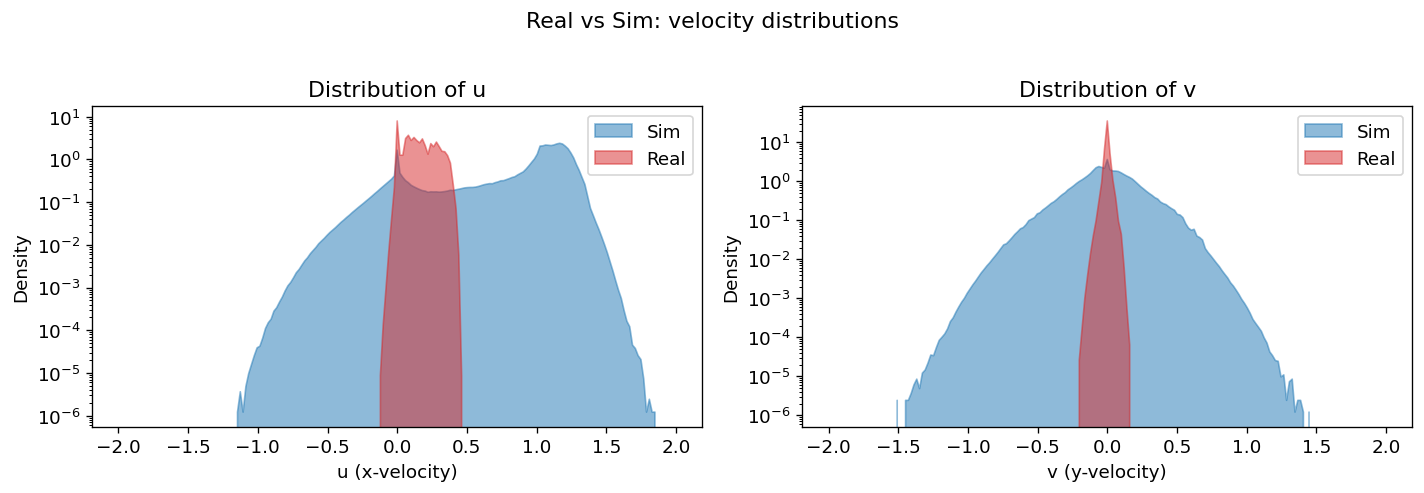

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, var, label in zip(axes, ["u", "v"], ["u (x-velocity)", "v (y-velocity)"]):
    d_sim, edges = sim_hists[var]
    d_real, _ = real_hists[var]
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.fill_between(centers, d_sim, alpha=0.5, label="Sim", color="C0")
    ax.fill_between(centers, d_real, alpha=0.5, label="Real", color="C3")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.set_yscale("log")
    ax.legend()
    ax.set_title(f"Distribution of {var}")

fig.suptitle("Real vs Sim: velocity distributions", y=1.02)
fig.tight_layout()
plt.show()

## 5. Distribution of p (Sim only)

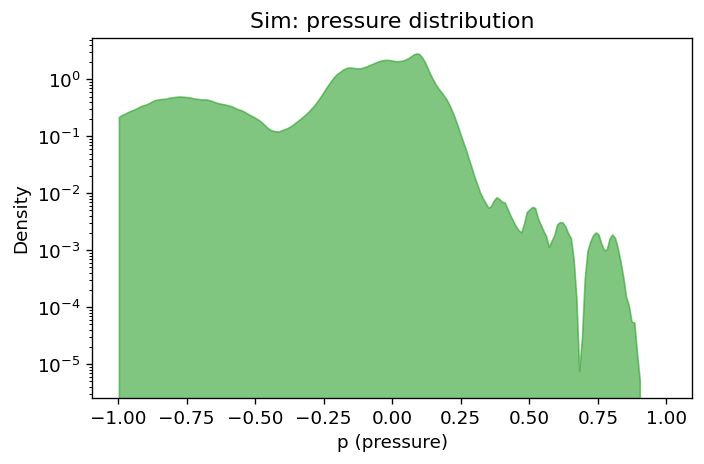

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
d_p, edges = sim_hists["p"]
centers = 0.5 * (edges[:-1] + edges[1:])
ax.fill_between(centers, d_p, alpha=0.6, color="C2")
ax.set_xlabel("p (pressure)")
ax.set_ylabel("Density")
ax.set_yscale("log")
ax.set_title("Sim: pressure distribution")
fig.tight_layout()
plt.show()

## 6. Mach number and Speed distributions (Real vs Sim)

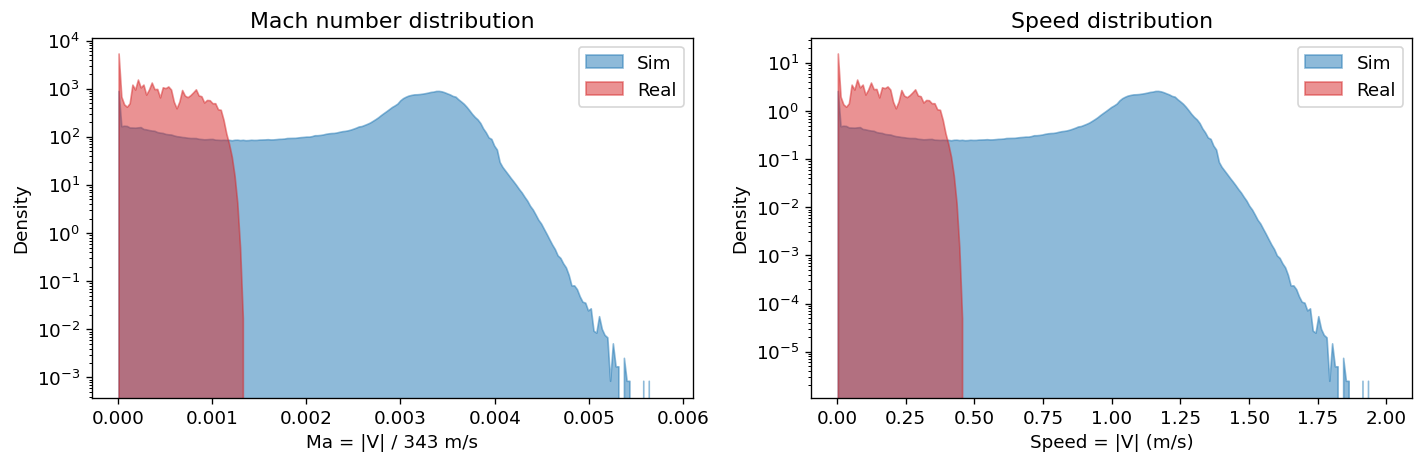

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mach
ax = axes[0]
d_sim_ma, edges_ma = sim_hists["ma"]
d_real_ma, _ = real_hists["ma"]
centers_ma = 0.5 * (edges_ma[:-1] + edges_ma[1:])
ax.fill_between(centers_ma, d_sim_ma, alpha=0.5, label="Sim", color="C0")
ax.fill_between(centers_ma, d_real_ma, alpha=0.5, label="Real", color="C3")
ax.set_xlabel(f"Ma = |V| / {SPEED_OF_SOUND:.0f} m/s")
ax.set_ylabel("Density")
ax.set_yscale("log")
ax.legend()
ax.set_title("Mach number distribution")

# Speed
ax = axes[1]
d_sim_spd, edges_spd = sim_hists["speed"]
d_real_spd, _ = real_hists["speed"]
centers_spd = 0.5 * (edges_spd[:-1] + edges_spd[1:])
ax.fill_between(centers_spd, d_sim_spd, alpha=0.5, label="Sim", color="C0")
ax.fill_between(centers_spd, d_real_spd, alpha=0.5, label="Real", color="C3")
ax.set_xlabel("Speed = |V| (m/s)")
ax.set_ylabel("Density")
ax.set_yscale("log")
ax.legend()
ax.set_title("Speed distribution")

fig.tight_layout()
plt.show()

## 7. Per-file mean stats (grouped by Re)

In [8]:
def build_file_df(file_stats):
    """Convert list of dicts to dict-of-lists for easy Re grouping."""
    keys = file_stats[0].keys()
    return {k: [d[k] for d in file_stats] for k in keys}

sim_df = build_file_df(sim_file_stats)
real_df = build_file_df(real_file_stats)

# Print summary
print(f"Sim:  {len(sim_df['file'])} files, Re values: {sorted(set(sim_df['re']))}")
print(f"Real: {len(real_df['file'])} files, Re values: {sorted(set(real_df['re']))}")

Sim:  100 files, Re values: [3750, 5025, 6300, 7575, 8850, 10125, 11400, 12675, 13950, 15225, 16500, 17775, 19050, 20325, 21600, 22875, 24150, 25425, 26700, 27975]
Real: 82 files, Re values: [3750, 5028, 6306, 7585, 8863, 10142, 11420, 12698, 13977, 16534, 17812, 19090, 20369, 21647, 22926, 24204, 25482, 26761]


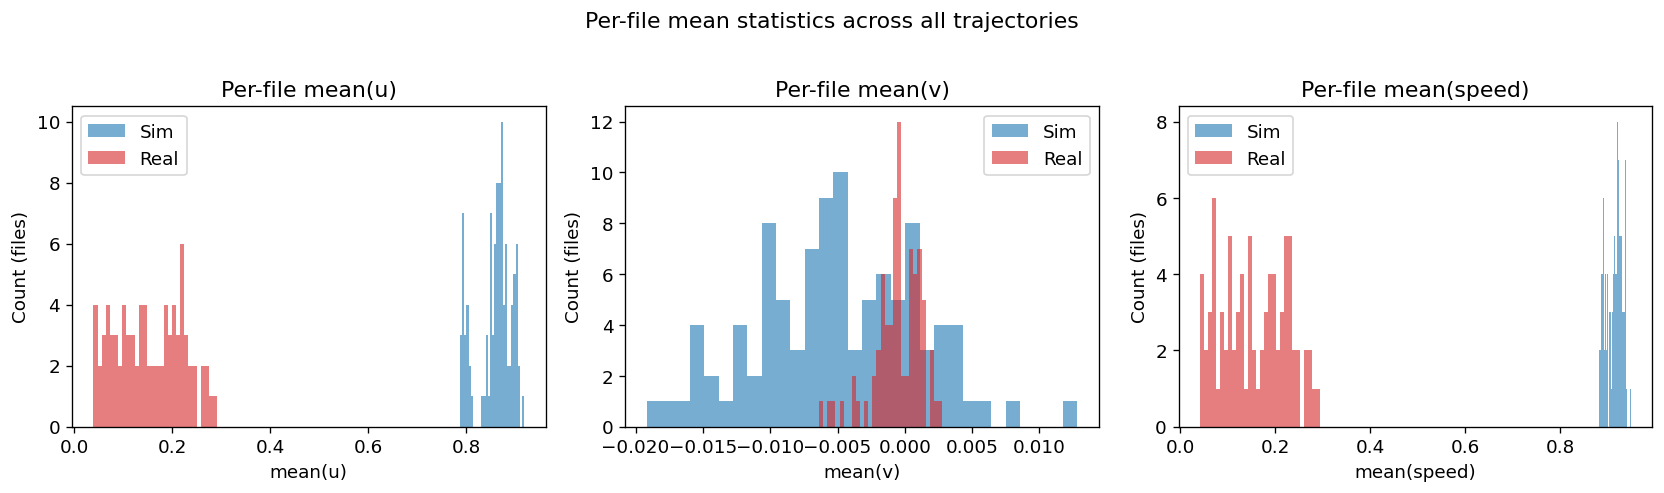

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var, label in zip(axes, ["u_mean", "v_mean", "speed_mean"], ["mean(u)", "mean(v)", "mean(speed)"]):
    ax.hist(sim_df[var], bins=30, alpha=0.6, label="Sim", color="C0")
    ax.hist(real_df[var], bins=30, alpha=0.6, label="Real", color="C3")
    ax.set_xlabel(label)
    ax.set_ylabel("Count (files)")
    ax.legend()
    ax.set_title(f"Per-file {label}")

fig.suptitle("Per-file mean statistics across all trajectories", y=1.02)
fig.tight_layout()
plt.show()

## 8. Box plots by Reynolds number

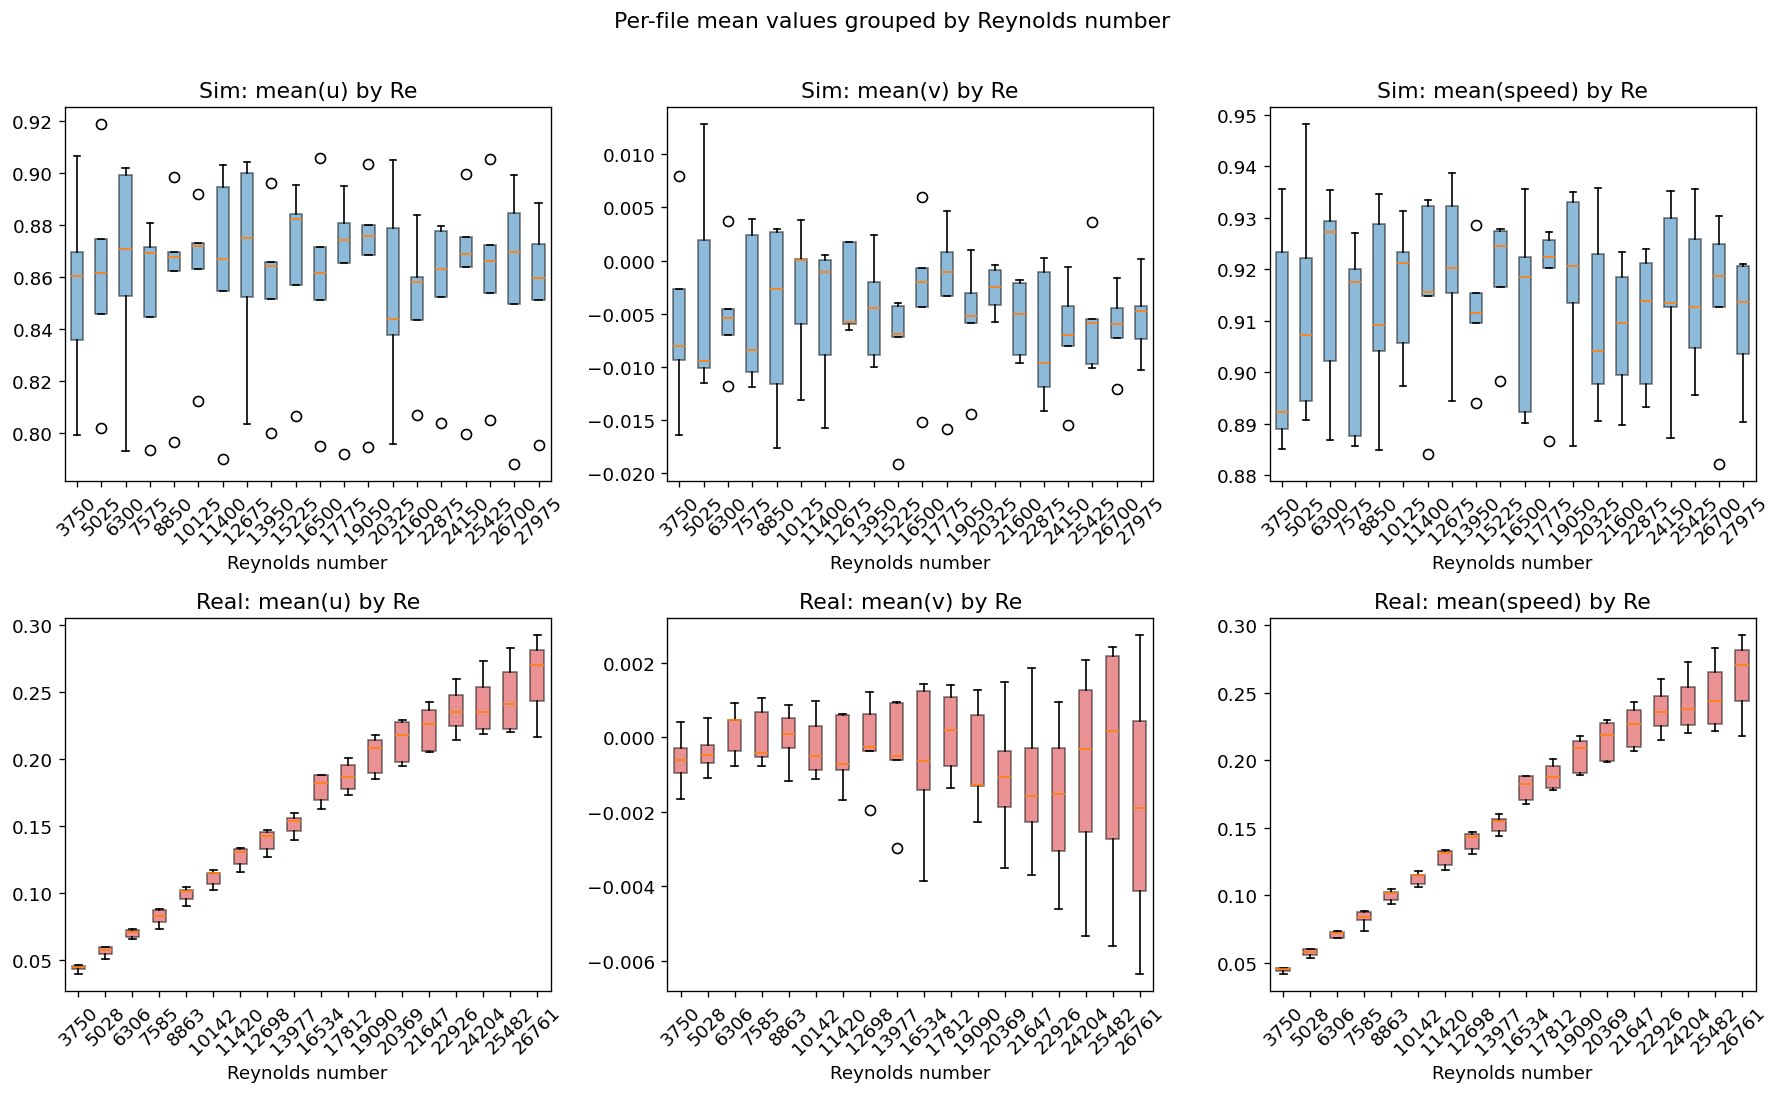

In [11]:
def boxplot_by_re(df, var, re_vals, color, ax):
    """Draw boxplot of var grouped by re_vals from a dict-of-lists df."""
    data = []
    labels = []
    for re in re_vals:
        vals = [df[var][i] for i in range(len(df["re"])) if df["re"][i] == re]
        if vals:
            data.append(vals)
            labels.append(str(re))
    if data:
        bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.5)

sim_re = sorted(set(sim_df["re"]))
real_re = sorted(set(real_df["re"]))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (var, label) in enumerate([("u_mean", "mean(u)"), ("v_mean", "mean(v)"), ("speed_mean", "mean(speed)")]):
    boxplot_by_re(sim_df, var, sim_re, "C0", axes[0, col])
    axes[0, col].set_title(f"Sim: {label} by Re")
    axes[0, col].set_xlabel("Reynolds number")
    axes[0, col].tick_params(axis="x", rotation=45)

    boxplot_by_re(real_df, var, real_re, "C3", axes[1, col])
    axes[1, col].set_title(f"Real: {label} by Re")
    axes[1, col].set_xlabel("Reynolds number")
    axes[1, col].tick_params(axis="x", rotation=45)

fig.suptitle("Per-file mean values grouped by Reynolds number", y=1.01)
fig.tight_layout()
plt.show()